# Cross-chromosome consistency of the per-sample founder-frequency estimates

**QC for the GWAS phenotype — and what drives it.** The multisite founder-GWAS trait is built from each
pool's **genome-wide** founder frequency $h$ (a 231-vector of ecotype proportions), which `genome_h()`
forms by **averaging the five chromosome-wide `ChrN_global_h` estimates** kMate's global-mode k-mer EM
produces per sample. This notebook asks **how much those five per-chromosome estimates agree within a
sample**, and then tests *why* they disagree: sequencing depth, recombination, or mixture identifiability.

## Metrics

For each sample, over its five chromosome vectors $h_c$ ($c\in$Chr1..Chr5, each 231-dim, sums to 1):

- **mean pairwise $r$** — mean Pearson correlation over the 10 chromosome pairs → agreement on *shape*
  (which founders dominate, in what order).
- **mean pairwise TV** — total variation $\tfrac12\sum_f|h_{c,f}-h_{c',f}|$, averaged over pairs → the
  *fraction of founder mass that disagrees* (0 = identical, 1 = disjoint).
- **eff. #founders** $=1/\sum_f h_f^2$ (mean over chromosomes) → how *concentrated* the mixture is
  (large = flat/many founders, small = a few winners dominate).

$r$ and TV answer different questions: $r$ can be high (consistent ranking) while TV is non-trivial (the
exact proportions still differ).

## Load the per-sample agreement table

In [1]:
import os
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
os.chdir("/global/scratch/users/tbellg/kmate")
H = "results/grenenet_gea/hapfreq"; CHROMS = ["Chr1","Chr2","Chr3","Chr4","Chr5"]
df = pd.read_csv(f"{H}/cross_chrom_agreement_full.csv")   # cohort + g0 seed mix; metrics + gen + coverage
print(f"{len(df):,} samples ({int((df.generation==0).sum())} g0 seed mix + cohort) | cols: {list(df.columns)}")

2,176 samples (8 g0 seed mix + cohort) | cols: ['sampleid', 'mean_r', 'min_r', 'mean_tv', 'max_tv', 'eff_n_mean', 'eff_n_cv', 'r_Chr1', 'r_Chr2', 'r_Chr3', 'r_Chr4', 'r_Chr5', 'coverage', 'generation']


In [2]:
q = [0.05,0.25,0.5,0.75,0.95]
coh = df[df.generation>0]                                  # cohort only for the headline QC numbers
summ = coh[["mean_r","min_r","mean_tv"]].quantile(q).T; summ.columns=[f"p{int(x*100)}" for x in q]
print("per-sample cross-chromosome agreement (cohort, n=%d):"%len(coh)); display(summ.round(3))
print(f"median mean pairwise r  = {coh.mean_r.median():.3f}  (shape agreement)")
print(f"median mean pairwise TV = {coh.mean_tv.median():.3f}  (~fraction of founder mass disagreeing)")
print("\nper-chromosome median r vs genome-wide h (which chromosome agrees least):")
display(coh[[f"r_{c}" for c in CHROMS]].median().round(3).rename("median_r_to_gw").to_frame())

per-sample cross-chromosome agreement (cohort, n=2168):


,p5,p25,p50,p75,p95
mean_r,0.703,0.870,0.944,0.983,0.998
min_r,0.551,0.794,0.906,0.971,0.996
mean_tv,0.156,0.225,0.285,0.330,0.405


median mean pairwise r  = 0.944  (shape agreement)
median mean pairwise TV = 0.285  (~fraction of founder mass disagreeing)

per-chromosome median r vs genome-wide h (which chromosome agrees least):


,median_r_to_gw
r_Chr1,0.986
r_Chr2,0.981
r_Chr3,0.989
r_Chr4,0.966
r_Chr5,0.975


## Distribution of agreement (shape vs magnitude)

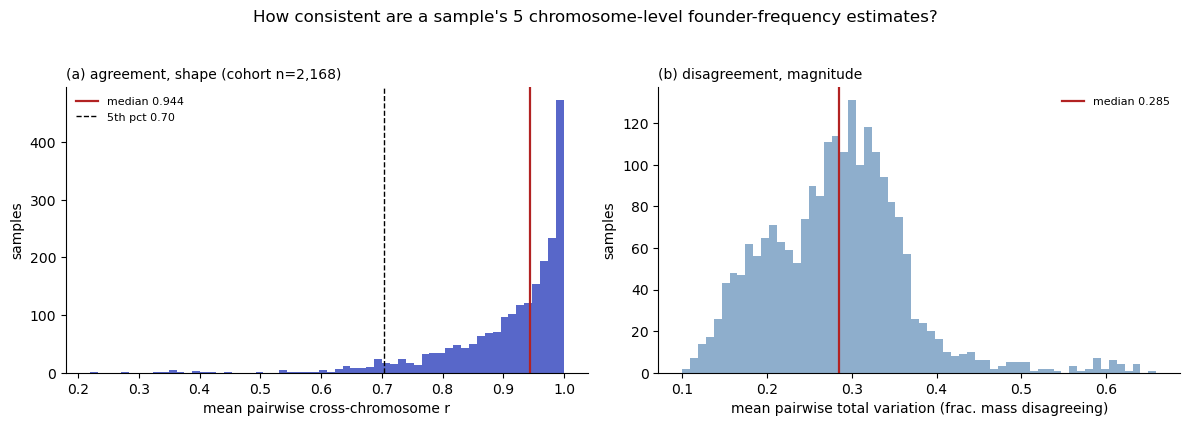

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3)); coh = df[df.generation>0]
ax[0].hist(coh.mean_r, bins=60, color="#3b4cc0", alpha=.85, edgecolor="none")
ax[0].axvline(coh.mean_r.median(), color="firebrick", lw=1.6, label=f"median {coh.mean_r.median():.3f}")
ax[0].axvline(coh.mean_r.quantile(.05), color="k", lw=1, ls="--", label=f"5th pct {coh.mean_r.quantile(.05):.2f}")
ax[0].set_xlabel("mean pairwise cross-chromosome r"); ax[0].set_ylabel("samples")
ax[0].set_title(f"(a) agreement, shape (cohort n={len(coh):,})", loc="left", fontsize=10)
ax[0].legend(frameon=False, fontsize=8); ax[0].spines[["top","right"]].set_visible(False)
ax[1].hist(coh.mean_tv, bins=60, color="#7aa0c4", alpha=.85, edgecolor="none")
ax[1].axvline(coh.mean_tv.median(), color="firebrick", lw=1.6, label=f"median {coh.mean_tv.median():.3f}")
ax[1].set_xlabel("mean pairwise total variation (frac. mass disagreeing)"); ax[1].set_ylabel("samples")
ax[1].set_title("(b) disagreement, magnitude", loc="left", fontsize=10)
ax[1].legend(frameon=False, fontsize=8); ax[1].spines[["top","right"]].set_visible(False)
fig.suptitle("How consistent are a sample's 5 chromosome-level founder-frequency estimates?", fontsize=12)
fig.tight_layout(rect=[0,0,1,0.95]); plt.show()

## Which chromosome agrees least

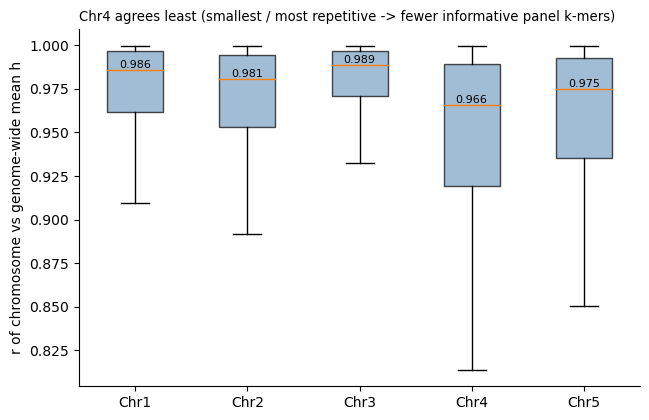

In [4]:
fig, ax = plt.subplots(figsize=(6.6, 4.3)); coh = df[df.generation>0]
bp = ax.boxplot([coh[f"r_{c}"] for c in CHROMS], labels=CHROMS, showfliers=False, patch_artist=True)
for b in bp["boxes"]: b.set(facecolor="#7aa0c4", alpha=.7)
for c,ch in enumerate(CHROMS,1): ax.text(c, coh[f"r_{CHROMS[c-1]}"].median(), f"{coh[f'r_{CHROMS[c-1]}'].median():.3f}", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("r of chromosome vs genome-wide mean h")
ax.set_title("Chr4 agrees least (smallest / most repetitive -> fewer informative panel k-mers)", loc="left", fontsize=9.5)
ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()

## Hypothesis 1 — is it sequencing depth?

Intuition says a low-coverage pool would give noisier per-chromosome estimates. **It doesn't.** Agreement
is essentially uncorrelated with coverage (below), including across the low-$r$ tail — so the disagreement
is not a sampling-depth artifact. (Consistent with the expectation that a *genome-wide* $h$ is stable
even at low depth.)

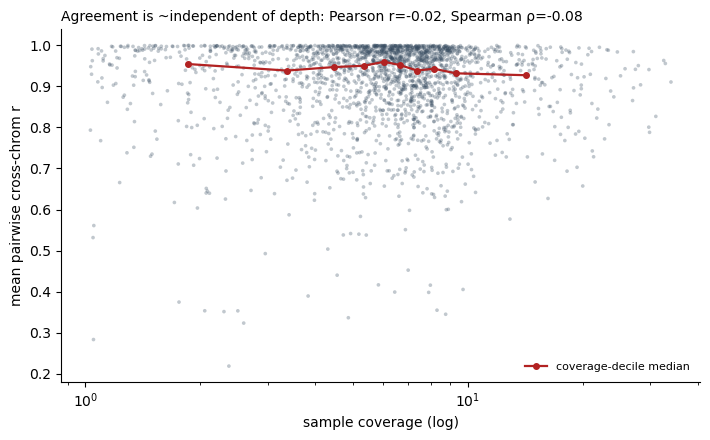

corr(agreement, coverage): Pearson -0.018 | Spearman -0.079 -> NOT a depth artifact


In [5]:
coh = df[df.generation>0]; m = coh.coverage.notna()
r_lin = float(np.corrcoef(coh.mean_r[m], coh.coverage[m])[0,1]); rho = float(stats.spearmanr(coh.mean_r[m], coh.coverage[m]).correlation)
fig, ax = plt.subplots(figsize=(7.2, 4.5))
cov = coh.coverage[m].to_numpy(); mr = coh.mean_r[m].to_numpy()
ax.scatter(cov, mr, s=7, c="#34495e", alpha=.3, edgecolors="none")
edges = np.quantile(cov, np.linspace(0, 1, 11)); binid = np.clip(np.digitize(cov, edges[1:-1]), 0, 9)
covd = [np.median(cov[binid==k]) for k in range(10) if (binid==k).any()]
mrd  = [np.median(mr[binid==k]) for k in range(10) if (binid==k).any()]
ax.plot(covd, mrd, "-o", color="firebrick", lw=1.6, ms=4, label="coverage-decile median")
ax.set_xscale("log"); ax.set_xlabel("sample coverage (log)"); ax.set_ylabel("mean pairwise cross-chrom r")
ax.set_title(f"Agreement is ~independent of depth: Pearson r={r_lin:.2f}, Spearman \u03c1={rho:.2f}", loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=8); ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()
print(f"corr(agreement, coverage): Pearson {r_lin:.3f} | Spearman {rho:.3f} -> NOT a depth artifact")

## Hypothesis 2 — is it recombination?

If recombination + chromosome-differential selection let chromosomes evolve semi-independently, agreement
should be **tight in the unrecombined g0 seed mix** and **fall with generation**. The data show the
**opposite**: the g0 seed mix has the *worst* agreement and agreement *rises* g0 → gen3. So recombination
is **not** the driver — chromosomes *converge* over time, they don't diverge.

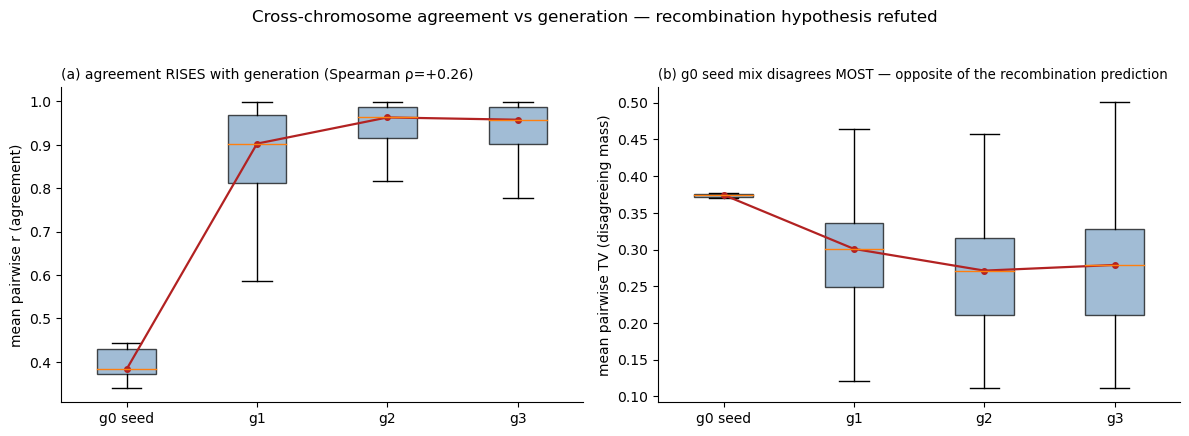

              n  median_mean_r  median_eff_n
generation                                  
0             8          0.383       115.783
1           897          0.903        21.752
2           763          0.963         8.357
3           508          0.958         8.388


In [6]:
gens = sorted(df.generation.unique())
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
for axi, col, lab in [(ax[0],"mean_r","mean pairwise r (agreement)"),(ax[1],"mean_tv","mean pairwise TV (disagreeing mass)")]:
    data=[df[df.generation==gg][col] for gg in gens]
    bp=axi.boxplot(data, labels=[f"g{gg}"+(" seed" if gg==0 else "") for gg in gens], showfliers=False, patch_artist=True)
    for b in bp["boxes"]: b.set(facecolor="#7aa0c4", alpha=.7)
    axi.plot(range(1,len(gens)+1),[df[df.generation==gg][col].median() for gg in gens],"-o",color="firebrick",lw=1.6,ms=4)
    axi.set_ylabel(lab); axi.spines[["top","right"]].set_visible(False)
rho=stats.spearmanr(df.generation, df.mean_r).correlation
ax[0].set_title(f"(a) agreement RISES with generation (Spearman \u03c1={rho:+.2f})", loc="left", fontsize=10)
ax[1].set_title("(b) g0 seed mix disagrees MOST — opposite of the recombination prediction", loc="left", fontsize=9.5)
fig.suptitle("Cross-chromosome agreement vs generation — recombination hypothesis refuted", fontsize=12)
fig.tight_layout(rect=[0,0,1,0.95]); plt.show()
print(df.groupby("generation").agg(n=("mean_r","size"), median_mean_r=("mean_r","median"), median_eff_n=("eff_n_mean","median")).round(3).to_string())

## The mechanism — mixture identifiability (effective #founders)

The g0 seed mix is ~231 founders at near-equal frequency: a **flat, maximally non-identifiable** mixture,
so each chromosome's k-mers resolve the 231-way ambiguity differently → low agreement. **Selection then
concentrates** frequency onto a few winners (eff. #founders falls from ~22 at gen1 to ~8 by gen3), the
likelihood sharpens, and all chromosomes agree. Agreement is almost a deterministic function of how
concentrated the mixture is — and this holds **within a single generation**, so it is not a generation
confound. This is the same non-identifiability that the [h-certainty] work flagged: per-founder $\hat h$
error is a bias from the *flat* likelihood manifold, not sampling variance.

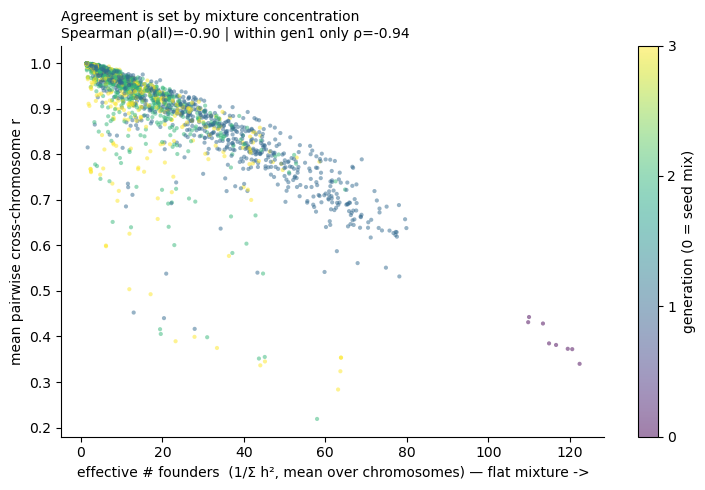

corr(mean_r, eff_n): Spearman all=-0.904 | within gen1=-0.937 (n=897)
-> concentrated (selected) mixtures are well-identified -> chromosomes agree; flat mixtures don't.


In [7]:
coh = df.copy()
rho_all = stats.spearmanr(coh.mean_r, coh.eff_n_mean).correlation
g1 = coh[coh.generation==1]; rho_g1 = stats.spearmanr(g1.mean_r, g1.eff_n_mean).correlation
fig, ax = plt.subplots(figsize=(7.6, 5))
sc = ax.scatter(coh.eff_n_mean, coh.mean_r, s=9, c=coh.generation, cmap="viridis", alpha=.5, edgecolors="none")
cb = plt.colorbar(sc, ax=ax, ticks=sorted(coh.generation.unique())); cb.set_label("generation (0 = seed mix)")
ax.set_xlabel("effective # founders  (1/\u03a3 h\u00b2, mean over chromosomes) — flat mixture ->");
ax.set_ylabel("mean pairwise cross-chromosome r")
ax.set_title(f"Agreement is set by mixture concentration\nSpearman \u03c1(all)={rho_all:.2f} | within gen1 only \u03c1={rho_g1:.2f}", loc="left", fontsize=10)
ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()
print(f"corr(mean_r, eff_n): Spearman all={rho_all:.3f} | within gen1={rho_g1:.3f} (n={len(g1)})")
print("-> concentrated (selected) mixtures are well-identified -> chromosomes agree; flat mixtures don't.")

## Takeaways (documentation)

- **Agreement is strong on structure, looser on magnitude.** In the cohort, median cross-chromosome
  $r=0.94$ (which founders dominate) but median TV $\approx0.28$ (~28% of founder mass differs between two
  chromosomes). Averaging the five into a genome-wide $h$ is therefore a justified **denoising** step.
- **Chr4 agrees least** (median $r$ to genome-wide 0.966 vs 0.989 for Chr3) — smallest / most repetitive,
  so fewer informative panel k-mers.
- **It is NOT sequencing depth.** Agreement is uncorrelated with coverage (Pearson ≈ Spearman ≈ 0) — a
  genome-wide $h$ is stable even at low depth, as expected.
- **It is NOT recombination.** Agreement *rises* g0 → gen3 and the unrecombined g0 seed mix is the *worst*;
  recombination would make chromosomes diverge over time, not converge.
- **It IS mixture identifiability.** Agreement is set by how concentrated the mixture is (eff. #founders):
  Spearman $\rho\approx-0.90$ overall and $\approx-0.94$ **within gen1 alone**. A flat ~231-founder seed
  mix is non-identifiable → chromosomes disagree; selection concentrates the pool onto a few winners →
  well-conditioned → chromosomes agree. So the cross-chromosome spread is a **non-identifiability bias of
  flat mixtures**, not noise or biology of recombination.
- **Implication for the GWAS.** The evolved pools that carry the selection signal (gen1–3, concentrated)
  are exactly where the genome-wide $h$ is *most* self-consistent — the disagreement concentrates in the
  near-uniform founding mix, where the per-founder split is inherently ambiguous. This is why the pipeline
  certifies the AF functional (which cancels the per-founder bias over carriers) rather than per-founder $h$.

*Source: `cross_chrom_agreement.py` (2,168 cohort samples) + `cross_chrom_by_generation.py` (adds the 8
g0 seed-mix pools); table `results/grenenet_gea/hapfreq/cross_chrom_agreement_full.csv`.*